In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.79MB/s]


In [4]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [5]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
class MLP(nn.Module):
    def __init__(self, hidden1, hidden2, activation):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "tanh":
            act = nn.Tanh()

        self.model = nn.Sequential(
            nn.Linear(28*28, hidden1),
            act,

            nn.Linear(hidden1, hidden2),
            act,

            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [7]:
def train_model(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ================= TRAIN =================
        model.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_losses[-1]:.4f} "
              f"Val Loss: {val_losses[-1]:.4f} "
              f"Val Acc: {val_accs[-1]*100:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

In [8]:
def evaluate(model):
    criterion = nn.CrossEntropyLoss()
    model.eval()

    test_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss /= len(test_loader)
    test_acc = correct / total

    return test_loss, test_acc

In [9]:
experiments = {
    "Experiment 1": {
        "hidden1": 128,
        "hidden2": 64,
        "activation": "relu",
        "lr": 0.001
    },
    "Experiment 2": {
        "hidden1": 256,
        "hidden2": 128,
        "activation": "tanh",
        "lr": 0.0005
    }
}

In [10]:
results = {}

for name, params in experiments.items():
    print("\n==============================")
    print("Running:", name)
    print("==============================")

    model = MLP(
        hidden1=params["hidden1"],
        hidden2=params["hidden2"],
        activation=params["activation"]
    )

    optimizer = optim.Adam(model.parameters(), lr=params["lr"])

    train_losses, val_losses, train_accs, val_accs = train_model(model, optimizer)

    test_loss, test_acc = evaluate(model)

    results[name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

    print(f"\n{name} Final Test Accuracy: {test_acc*100:.2f}%")


Running: Experiment 1
Epoch [1/10] Train Loss: 0.4331 Val Loss: 0.2520 Val Acc: 92.32%
Epoch [2/10] Train Loss: 0.2043 Val Loss: 0.1702 Val Acc: 94.61%
Epoch [3/10] Train Loss: 0.1462 Val Loss: 0.1400 Val Acc: 95.55%
Epoch [4/10] Train Loss: 0.1221 Val Loss: 0.1212 Val Acc: 96.36%
Epoch [5/10] Train Loss: 0.1011 Val Loss: 0.1133 Val Acc: 96.50%
Epoch [6/10] Train Loss: 0.0905 Val Loss: 0.1131 Val Acc: 96.62%
Epoch [7/10] Train Loss: 0.0809 Val Loss: 0.1022 Val Acc: 96.88%
Epoch [8/10] Train Loss: 0.0719 Val Loss: 0.1026 Val Acc: 96.89%
Epoch [9/10] Train Loss: 0.0653 Val Loss: 0.1000 Val Acc: 97.13%
Epoch [10/10] Train Loss: 0.0619 Val Loss: 0.1120 Val Acc: 96.84%

Experiment 1 Final Test Accuracy: 96.60%

Running: Experiment 2
Epoch [1/10] Train Loss: 0.3909 Val Loss: 0.2270 Val Acc: 93.10%
Epoch [2/10] Train Loss: 0.1791 Val Loss: 0.1426 Val Acc: 95.72%
Epoch [3/10] Train Loss: 0.1288 Val Loss: 0.1279 Val Acc: 96.15%
Epoch [4/10] Train Loss: 0.0990 Val Loss: 0.1224 Val Acc: 96.51%
E

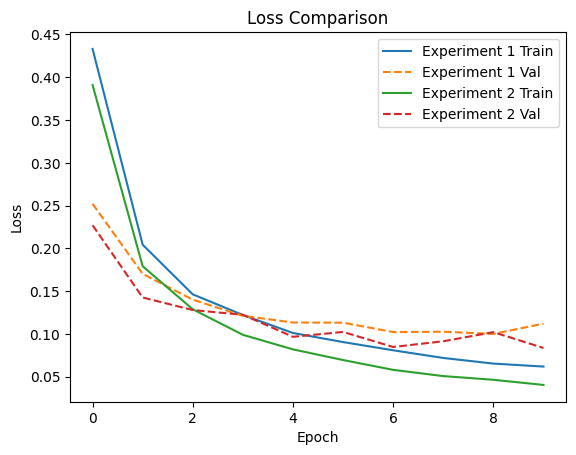

In [11]:
plt.figure()

for name in results:
    plt.plot(results[name]["train_losses"], label=f"{name} Train")
    plt.plot(results[name]["val_losses"], linestyle="dashed", label=f"{name} Val")

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

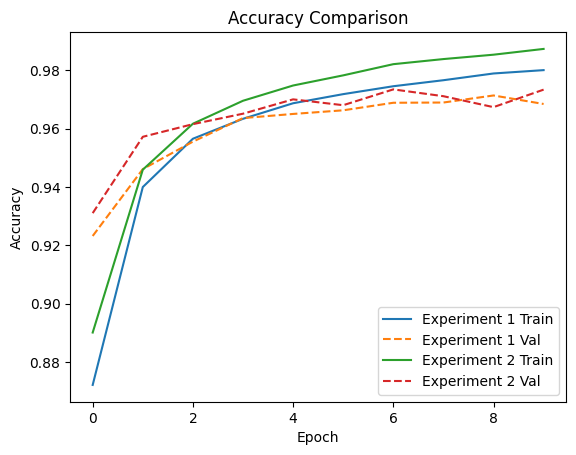

In [12]:
plt.figure()

for name in results:
    plt.plot(results[name]["train_accs"], label=f"{name} Train")
    plt.plot(results[name]["val_accs"], linestyle="dashed", label=f"{name} Val")

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
for name in results:
    print("\n", name)
    print("Test Loss:", round(results[name]["test_loss"], 4))
    print("Test Accuracy:", round(results[name]["test_acc"] * 100, 2), "%")


 Experiment 1
Test Loss: 0.1095
Test Accuracy: 96.6 %

 Experiment 2
Test Loss: 0.0855
Test Accuracy: 97.3 %
